# Stage 2 — Deep Exploratory Data Analysis

Building on Stage 1's cleaning and feature engineering. Each section asks one question, answers it with one chart, and ends with a takeaway.

Load Stage 1's fitted preprocessor and apply it to the full dataset.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

BASE_DIR = Path("..").resolve()
sys.path.insert(0, str(BASE_DIR))

preprocessor = joblib.load(BASE_DIR / "artifacts" / "preprocessing.pkl")
raw = pd.read_csv(BASE_DIR / "data" / "train.csv")
df = preprocessor.transform(raw)
df.shape

(891, 19)

Shared chart style, matching the palette used across the rest of the portfolio.

In [2]:
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
INK, INK_MUTED, NEUTRAL = "#0b0b0b", "#52514e", "#f0efec"
DIVERGING = LinearSegmentedColormap.from_list("diverging", [RED, NEUTRAL, BLUE])

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK_MUTED,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e8e7e3",
    "grid.linewidth": 0.6,
    "font.size": 10.5,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "figure.dpi": 110,
})


def label_bars(ax, values, fmt="{:.0%}", horizontal=True, pad=0.01):
    for bar, v in zip(ax.patches, values):
        if horizontal:
            ax.text(bar.get_width() + pad, bar.get_y() + bar.get_height() / 2,
                     fmt.format(v), va="center", fontsize=9.5, color=INK)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + pad,
                     fmt.format(v), ha="center", fontsize=9.5, color=INK)

## 2.1 Dataset Overview

What are we working with, and where are the gaps?

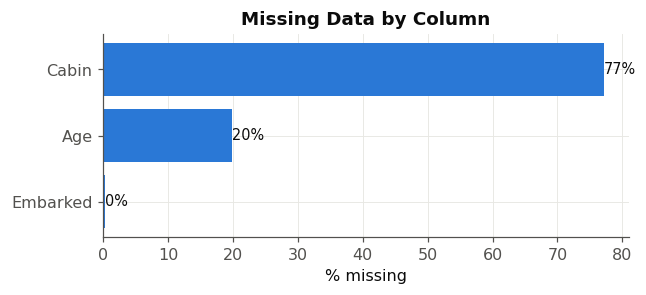

In [3]:
missing = raw.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0] * 100

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.barh(missing.index, missing.values, color=BLUE)
ax.invert_yaxis()
ax.set_xlabel("% missing")
ax.set_title("Missing Data by Column")
label_bars(ax, missing.values, fmt="{:.0f}%")
plt.tight_layout()
plt.show()

- Cabin: 77% missing — handled structurally via `HasCabin` / `Deck`, not filled
- Age: 20% missing — imputed with the per-Title median
- Embarked: <1% missing — imputed with the mode

**Takeaway**

Only two columns need real imputation; Cabin's gap is a signal, not a hole to patch.

Marginal missing rates don't show whether missingness co-occurs. A row-level matrix does.

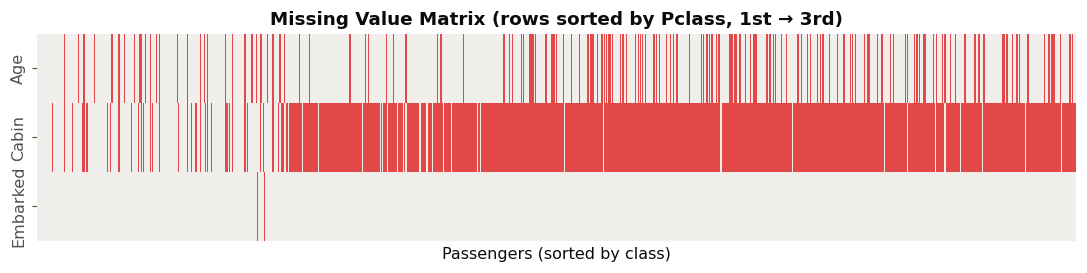

           Age  Cabin  Embarked
Age       1.00   0.14     -0.02
Cabin     0.14   1.00     -0.09
Embarked -0.02  -0.09      1.00


In [4]:
missing_cols = ["Age", "Cabin", "Embarked"]
missing_bool = raw[missing_cols].isna()
sort_order = raw["Pclass"].sort_values().index
matrix = missing_bool.loc[sort_order].astype(int).T

fig, ax = plt.subplots(figsize=(10, 2.6))
sns.heatmap(matrix, cmap=["#f0efec", RED], cbar=False, ax=ax,
            xticklabels=False, yticklabels=missing_cols)
ax.set_title("Missing Value Matrix (rows sorted by Pclass, 1st → 3rd)")
ax.set_xlabel("Passengers (sorted by class)")
plt.tight_layout()
plt.show()

print(raw[missing_cols].isna().astype(int).corr().round(2))

- Age-missing and Cabin-missing barely correlate with each other (r=0.14) — but both correlate strongly with `Pclass`: Cabin is missing for 98% of 3rd class vs. 19% of 1st; Age is missing for 28% of 3rd class vs. 14% of 1st
- The matrix makes the shared driver visible: a dense red block on the right (3rd class) for `Cabin`, a lighter but real density for `Age`

**Takeaway**

Missingness isn't independent noise — both gaps trace back to `Pclass`. That's exactly why Stage 1 imputes `Age` by a `Title`-based median (`Title` correlates with class) rather than a flat median, and treats `Cabin`'s absence as signal instead of noise.

## 2.2 Target Variable Analysis

How imbalanced is the outcome we're predicting?

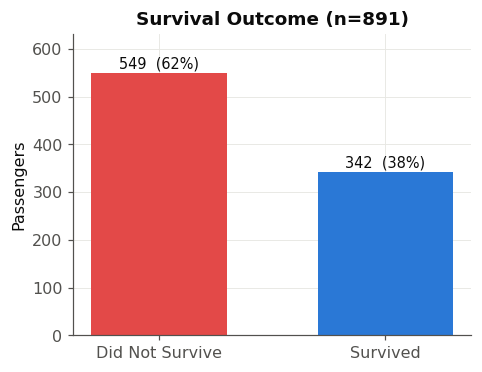

In [5]:
counts = df["Survived"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(4.5, 3.5))
bars = ax.bar(["Did Not Survive", "Survived"], counts.values, color=[RED, BLUE], width=0.6)
ax.set_title(f"Survival Outcome (n={len(df)})")
ax.set_ylabel("Passengers")
for b, c in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, c + 10, f"{c}  ({c / len(df):.0%})",
            ha="center", fontsize=9.5)
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

- 61.6% did not survive, 38.4% did
- Moderate imbalance — not severe enough to need resampling

**Takeaway**

Carry `class_weight="balanced"` into Stage 4 modeling; oversampling would be overkill.

## 2.3 Numerical Features

Do Age and Fare separate survivors from non-survivors?

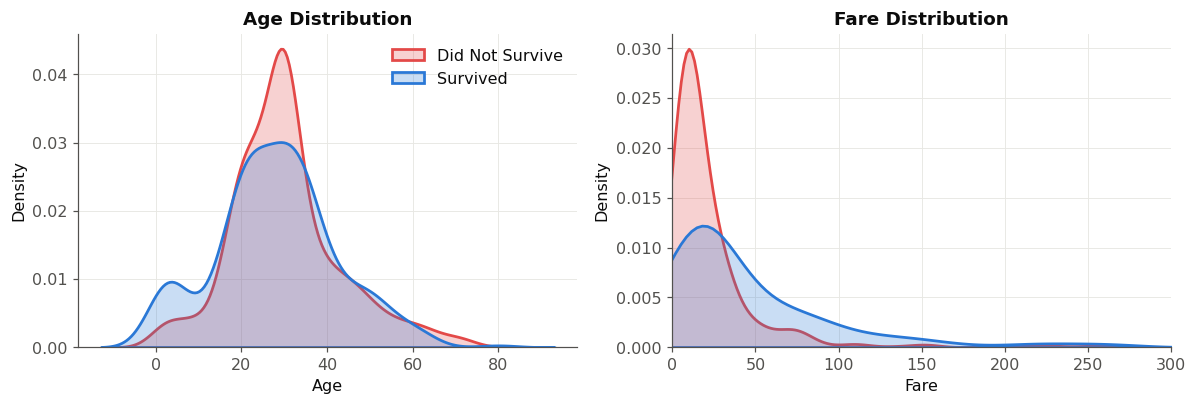

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for value, color, label in [(0, RED, "Did Not Survive"), (1, BLUE, "Survived")]:
    sns.kdeplot(df.loc[df.Survived == value, "Age"], ax=axes[0], color=color,
                label=label, fill=True, alpha=0.25, linewidth=1.8)
    sns.kdeplot(df.loc[df.Survived == value, "Fare"], ax=axes[1], color=color,
                label=label, fill=True, alpha=0.25, linewidth=1.8)
axes[0].set_title("Age Distribution")
axes[1].set_title("Fare Distribution")
axes[1].set_xlim(0, 300)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

- Age: nearly identical shape between groups, but survivors show a small child spike (<10)
- Fare: survivors skew toward higher fares; both groups have a heavy right tail

**Takeaway**

Fare separates outcomes more cleanly than Age — matches Stage 1's audit (r=0.257 vs. 0.079).

The KDE above shows *distribution shape* by outcome. It doesn't show the survival *rate* as age changes continuously.

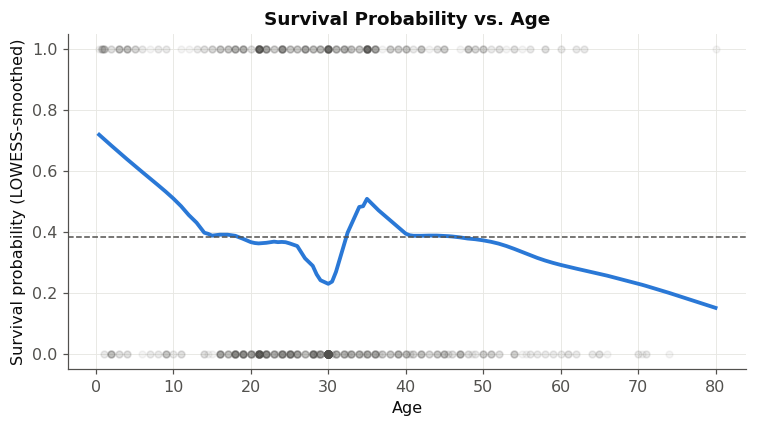

In [7]:
from statsmodels.nonparametric.smoothers_lowess import lowess

age_valid = df.dropna(subset=["Age"])
smoothed = lowess(age_valid["Survived"], age_valid["Age"], frac=0.35)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(age_valid["Age"], age_valid["Survived"], alpha=0.06, color=INK_MUTED, s=20)
ax.plot(smoothed[:, 0], smoothed[:, 1], color=BLUE, linewidth=2.5)
ax.axhline(age_valid["Survived"].mean(), color=INK_MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("Age")
ax.set_ylabel("Survival probability (LOWESS-smoothed)")
ax.set_title("Survival Probability vs. Age")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

- Survival probability peaks sharply under age 5 (~70%), well above the 38% baseline
- It drops through the teens and sits roughly flat (35-45%) across adulthood — not a steady decline, a plateau
- The elderly tail is too sparse (n<5 past age 65) to read as a real trend, not a finding

**Takeaway**

The relationship is non-monotonic, driven almost entirely by the youngest children — the same shape of problem as `FamilySize` (Stage 5). A single linear `Age` coefficient captures the average slope, not this curve; `AgeGroup`'s `Child` cutoff at 12 exists to catch exactly this spike.

## 2.4 Categorical Features

Which categorical splits carry the clearest signal?

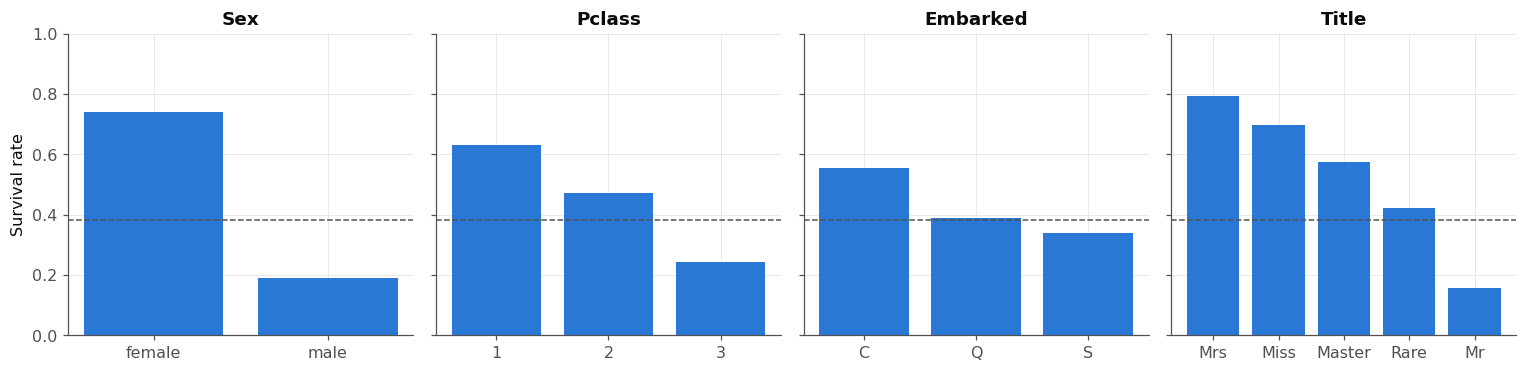

In [8]:
overall_rate = df["Survived"].mean()
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
for ax, col in zip(axes, ["Sex", "Pclass", "Embarked", "Title"]):
    rate = df.groupby(col, observed=True)["Survived"].mean().sort_values(ascending=False)
    ax.bar(rate.index.astype(str), rate.values, color=BLUE)
    ax.axhline(overall_rate, color=INK_MUTED, linewidth=1, linestyle="--")
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)
axes[0].set_ylabel("Survival rate")
plt.tight_layout()
plt.show()

- Sex is the single sharpest split (74% vs. 19%)
- Pclass and Title track Sex closely — expected overlap
- Embarked's spread is real but smaller, and likely a Pclass proxy (Stage 1, README Phase 1)

**Takeaway**

Sex, Pclass, and Title dominate — matches the Stage 1 statistical audit exactly.

## 2.5 Feature Relationships

Which features move together, ahead of formal VIF?

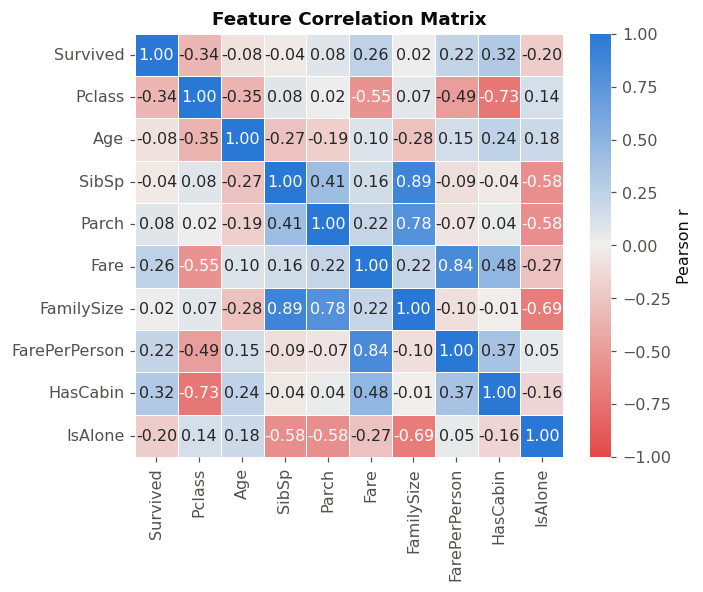

In [9]:
corr_features = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare",
                  "FamilySize", "FarePerPerson", "HasCabin", "IsAlone"]
corr = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

- `FamilySize` correlates strongly with both `SibSp` and `Parch` — expected, it's built from them
- `FarePerPerson` tracks `Fare` almost 1:1
- Nothing else clusters — no hidden redundancy elsewhere

**Takeaway**

Two redundancy candidates stand out; VIF (2.9) quantifies how serious they are.

## 2.6 Interaction Analysis

Does passenger class matter equally for men and women?

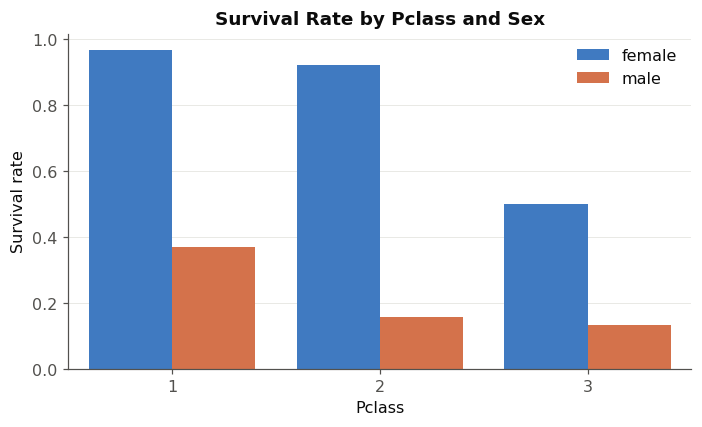

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex",
            palette={"female": BLUE, "male": ORANGE}, ax=ax, errorbar=None)
ax.set_ylabel("Survival rate")
ax.set_xlabel("Pclass")
ax.set_title("Survival Rate by Pclass and Sex")
ax.legend(frameon=False, title=None)
plt.tight_layout()
plt.show()

df["Sex_Pclass"] = df["Sex"] + "_" + df["Pclass"].astype(str)

- 1st-class women survive at 97%; 3rd-class men at 14% — the two extremes
- For men, even 1st class only reaches 37% — sex outweighs class almost entirely
- For women, the cliff is specifically 3rd class (92% → 50%), not a steady decline

**Takeaway**

Sex sets the baseline; Pclass reshapes it unevenly. `Sex_Pclass` is materialized above for Stage 3/4.

## 2.7 Outlier Analysis

Are the Fare and Age extremes data errors, or real passengers?

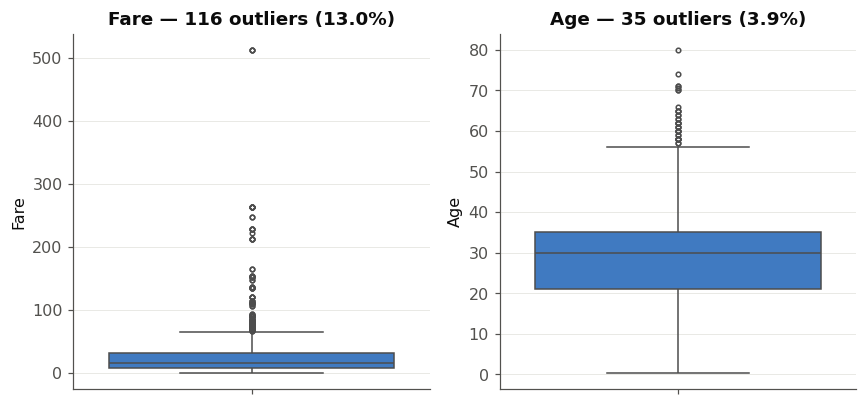

In [11]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

fare_out, age_out = iqr_outliers(df["Fare"]), iqr_outliers(df["Age"])

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
sns.boxplot(y=df["Fare"], ax=axes[0], color=BLUE, fliersize=3)
sns.boxplot(y=df["Age"], ax=axes[1], color=BLUE, fliersize=3)
axes[0].set_title(f"Fare — {fare_out} outliers ({fare_out / len(df):.1%})")
axes[1].set_title(f"Age — {age_out} outliers ({age_out / len(df):.1%})")
plt.tight_layout()
plt.show()

- Fare: 13% flagged by IQR — mostly large families and 1st-class group tickets, not errors
- Age: 4% flagged — a handful of elderly passengers, also legitimate

**Takeaway**

No removals. Tree-based models handle these natively; a log-transform (2.8) helps only if using linear models.

## 2.8 Distribution Analysis

Does a log-transform fix Fare's skew?

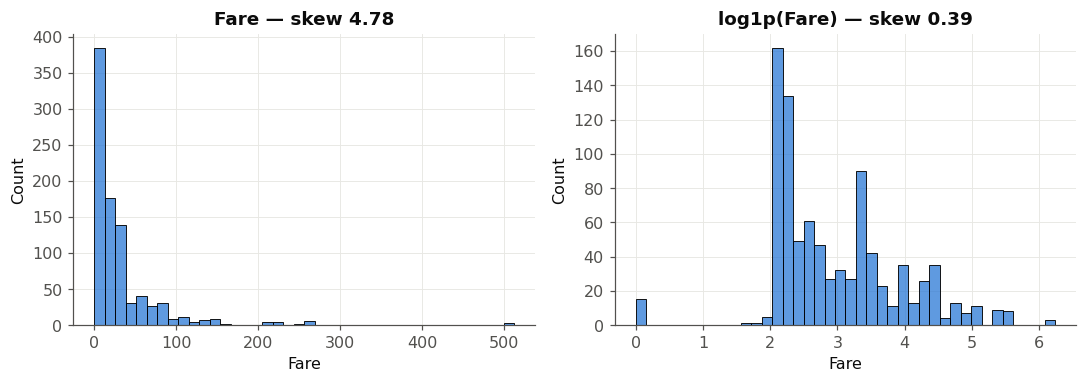

In [12]:
fare_log = np.log1p(df["Fare"])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
sns.histplot(df["Fare"], bins=40, color=BLUE, ax=axes[0])
sns.histplot(fare_log, bins=40, color=BLUE, ax=axes[1])
axes[0].set_title(f"Fare — skew {stats.skew(df['Fare']):.2f}")
axes[1].set_title(f"log1p(Fare) — skew {stats.skew(fare_log):.2f}")
plt.tight_layout()
plt.show()

- Raw Fare: skew 4.78, kurtosis 33.2 — extreme right tail
- log1p(Fare): skew 0.39, kurtosis 0.96 — close to normal

**Takeaway**

Worth adding for Logistic Regression; irrelevant for Random Forest / Gradient Boosting, which split on raw values regardless of scale.

## 2.9 Multicollinearity (VIF)

How serious is the redundancy the correlation map flagged?

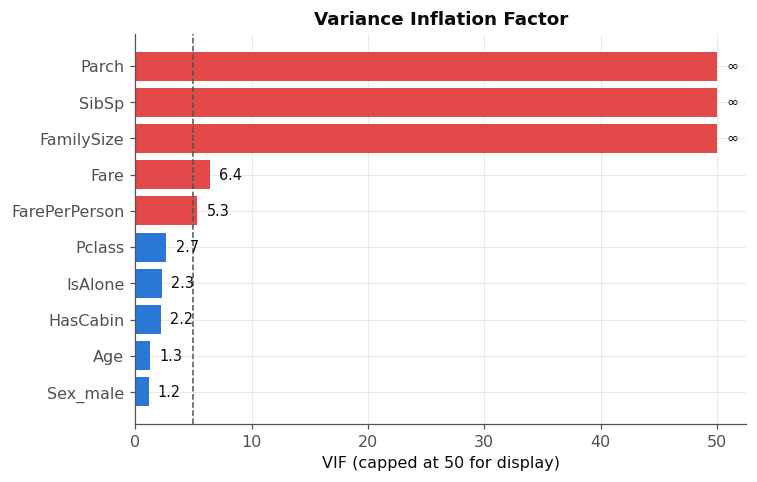

In [13]:
X = df[["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize",
        "FarePerPerson", "HasCabin", "IsAlone"]].copy()
X["Sex_male"] = (df["Sex"] == "male").astype(int)
X_const = X.assign(const=1.0)

vif = pd.Series(
    [variance_inflation_factor(X_const.values, i) for i in range(X.shape[1])],
    index=X.columns,
).sort_values(ascending=False)

display_vif = vif.replace(np.inf, 50)
colors = [RED if v > 5 else BLUE for v in vif]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(vif.index, display_vif.values, color=colors)
ax.invert_yaxis()
ax.axvline(5, color=INK_MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("VIF (capped at 50 for display)")
ax.set_title("Variance Inflation Factor")
for bar, v in zip(ax.patches, vif.values):
    label = "∞" if np.isinf(v) else f"{v:.1f}"
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=9.5)
plt.tight_layout()
plt.show()

- `SibSp`, `Parch`, `FamilySize`: VIF is literally infinite — `FamilySize = SibSp + Parch + 1` by construction
- `Fare` and `FarePerPerson`: VIF 6.4 and 5.3 — both above the standard threshold of 5
- `Pclass`, `IsAlone`, `HasCabin`, `Age`, `Sex`: all under 3 — no concern

**Takeaway**

Never train with `SibSp`, `Parch`, and `FamilySize` together. `Fare` and `FarePerPerson` are also redundant — Stage 3 keeps one, not both.

## 2.10 Feature Importance Preview

Which features would a model actually lean on?

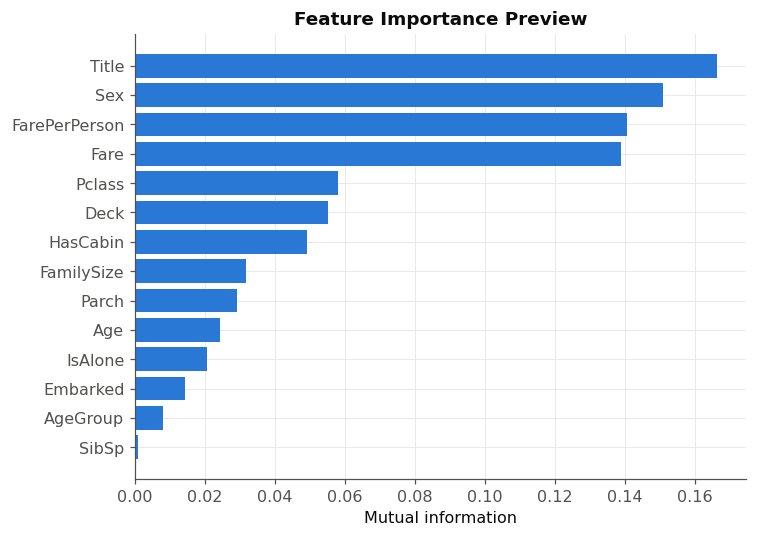

In [14]:
mi_features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked",
               "HasCabin", "FamilySize", "IsAlone", "Title", "FarePerPerson",
               "Deck", "AgeGroup"]
categorical_cols = ["Pclass", "Sex", "Embarked", "Title", "Deck", "AgeGroup"]

X_mi = df[mi_features].copy()
for col in categorical_cols:
    X_mi[col] = LabelEncoder().fit_transform(X_mi[col].astype(str))

discrete_mask = [c in categorical_cols + ["HasCabin", "IsAlone"] for c in mi_features]
mi = mutual_info_classif(X_mi, df["Survived"], discrete_features=discrete_mask, random_state=42)
mi_ranked = pd.Series(mi, index=mi_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(mi_ranked.index, mi_ranked.values, color=BLUE)
ax.invert_yaxis()
ax.set_xlabel("Mutual information")
ax.set_title("Feature Importance Preview")
plt.tight_layout()
plt.show()

- `Title`, `Sex`, `FarePerPerson`, `Fare` lead — matches the Stage 1 audit
- `Deck` (0.055) edges out `HasCabin` (0.049) — marginal, and Deck still carries the sparsity problem flagged in Stage 1
- Raw `Age` (0.024) beats `AgeGroup` (0.008) — binning loses signal here; `SibSp` alone is next to worthless (0.001)

**Takeaway**

Resolves two Stage 1 open questions: Deck edges out HasCabin on raw signal, but Stage 3 still weighs that against sparsity. Raw Age beats AgeGroup outright.

## 2.11 Stage Summary

**Confirmed from Stage 1**
- Sex, Title, and Pclass remain the strongest predictors
- FamilySize's effect is real but non-linear (Section 2.6 shows why)

**New evidence for Stage 3**
- `SibSp` + `Parch` + `FamilySize` together are perfectly collinear (VIF = ∞) — keep one representation
- `Fare` and `FarePerPerson` are redundant (VIF 6.4 / 5.3) — keep one
- `Deck` (MI 0.055) narrowly beats `HasCabin` (MI 0.049), but its sparsity issue still stands
- Raw `Age` (MI 0.024) beats `AgeGroup` (MI 0.008) — binning loses signal

**Carried into Stage 3**

Final feature selection resolves: `FamilySize` vs. `SibSp`/`Parch`, `Fare` vs. `FarePerPerson`, `Deck` vs. `HasCabin`, `Age` vs. `AgeGroup`.

## Feature Selection Journey

How Stages 1-3 got from 11 raw candidate features to the final 8.

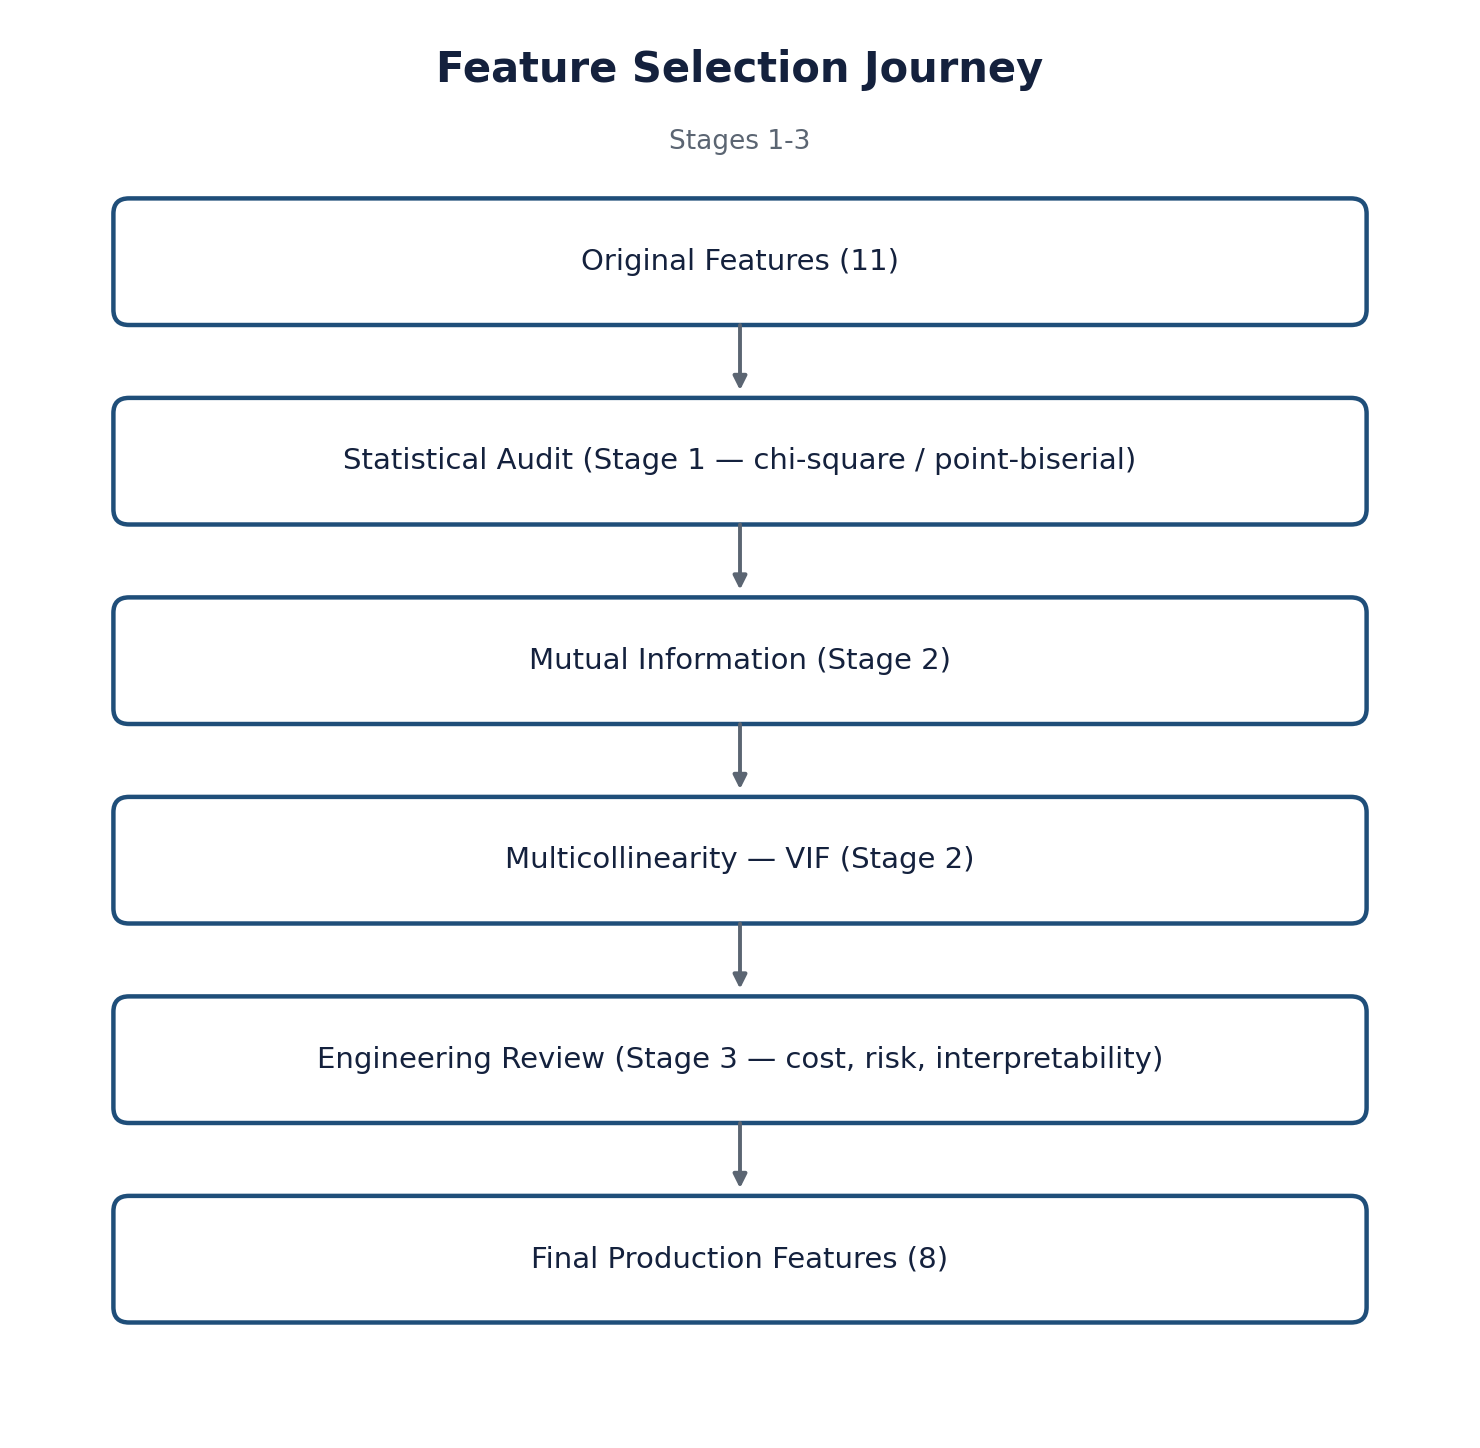

In [15]:
from IPython.display import Image

Image(filename="../docs/feature-selection-journey.png", width=650)

Full per-feature evidence and reasoning: `reports/stage3_feature_selection.md`.